In [ ]:
import pandas as pd        # Data loading & cleaning
import numpy as np         # Numerical operations
import matplotlib.pyplot as plt   # Visualization
import seaborn as sns      # Advanced visualization

In [ ]:
df=pd.read_csv('stroke_patients.csv')
df

,patient_id,age,gender,marital_status,smoking_status,alcohol_intake,physical_activity_level,sleep_hours,hypertension,heart_disease,...,diastolic_bp,blood_glucose_level,headache_frequency,vision_problems,speech_difficulty,numbness_or_weakness,confusion_level,stroke_history,stroke_risk_score,stroke_occurred
0,mostly36-0fa9-4b4d-aad0-b32209221607,52,female,married,never,none,low,6.9,0,0,...,78,98,occasional,no,no,no,low,0,0.05,0
1,mostly93-40ec-4d4a-9e7d-ee194f1dd0f4,72,male,widowed,formerly,occasional,low,6.1,1,1,...,92,128,frequent,yes,yes,yes,moderate,0,0.66,0
2,mostlye6-6e12-44c0-98ea-85b6d2eec3d1,59,male,married,formerly,heavy,low,6.8,1,0,...,78,198,occasional,no,no,no,low,0,0.19,0
3,mostly3a-3d91-4a12-b209-30ae864114bb,68,female,married,currently,occasional,low,6.5,1,1,...,96,264,frequent,yes,yes,yes,severe,1,0.89,1
4,mostly24-531e-41f6-bb4e-35f4b2ca3f04,72,female,married,formerly,occasional,low,6.5,1,1,...,98,264,frequent,yes,yes,yes,moderate,1,0.92,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,mostly56-b7ea-4e90-a870-f8f77546a60b,52,male,married,currently,occasional,low,6.8,1,0,...,86,190,occasional,no,no,yes,low,0,0.28,0
49996,mostly8c-e399-48ba-b222-264cd4a83082,57,male,married,never,none,low,6.0,1,0,...,82,94,occasional,no,no,no,low,0,0.12,0
49997,mostly10-7920-4a23-a9de-b304c7519818,63,female,married,currently,heavy,low,6.0,1,1,...,94,128,occasional,yes,no,yes,moderate,0,0.64,0
49998,mostly94-7f2a-4907-91ec-344601eef3d2,51,female,married,never,none,low,7.0,0,0,...,86,98,occasional,no,no,no,low,0,0.12,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   gender                   50000 non-null  object 
 3   marital_status           50000 non-null  object 
 4   smoking_status           50000 non-null  object 
 5   alcohol_intake           50000 non-null  object 
 6   physical_activity_level  50000 non-null  object 
 7   sleep_hours              50000 non-null  float64
 8   hypertension             50000 non-null  int64  
 9   heart_disease            50000 non-null  int64  
 10  diabetes                 50000 non-null  int64  
 11  cholesterol_level        50000 non-null  object 
 12  bmi                      50000 non-null  float64
 13  systolic_bp              50000 non-null  int64  
 14  diastolic_bp          

In [ ]:
# Shape
print("Rows:", df.shape[0], "Columns:", df.shape[1])

Rows: 50000 Columns: 24


In [ ]:
df.describe()

,age,sleep_hours,hypertension,heart_disease,diabetes,bmi,systolic_bp,diastolic_bp,blood_glucose_level,stroke_history,stroke_risk_score,stroke_occurred
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,61.189660,6.342894,0.781620,0.370320,0.271160,28.83173,140.448640,87.803120,125.32224,0.166600,0.432546,0.159080
std,8.479694,0.697217,0.413151,0.482895,0.444563,3.76953,13.746961,7.146407,42.24976,0.372622,0.296020,0.365754
min,42.000000,5.000000,0.000000,0.000000,0.000000,21.90000,112.000000,70.000000,88.00000,0.000000,0.010000,0.000000
25%,55.000000,5.900000,1.000000,0.000000,0.000000,25.90000,130.000000,82.000000,100.00000,0.000000,0.180000,0.000000
50%,60.000000,6.300000,1.000000,0.000000,0.000000,28.70000,142.000000,88.000000,108.00000,0.000000,0.410000,0.000000
75%,68.000000,6.800000,1.000000,1.000000,1.000000,31.70000,150.000000,92.000000,125.00000,0.000000,0.660000,0.000000
max,79.000000,7.800000,1.000000,1.000000,1.000000,36.40000,172.000000,105.000000,264.00000,1.000000,0.990000,1.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Target column ka distribution
df['stroke_occurred'].value_counts()

,count
stroke_occurred,
0,42046
1,7954


In [ ]:
df['stroke_occurred'].value_counts(normalize=True)

,proportion
stroke_occurred,
0,0.84092
1,0.15908


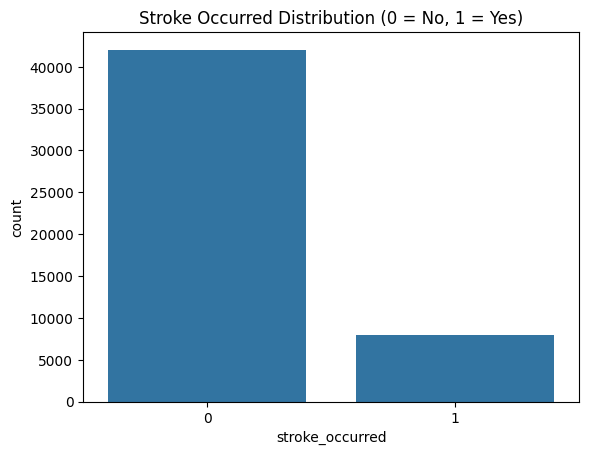

In [ ]:
sns.countplot(x='stroke_occurred', data=df)
plt.title("Stroke Occurred Distribution (0 = No, 1 = Yes)")
plt.show()


In [ ]:
# Categorical columns
categorical_cols=df.select_dtypes(include=['object']).columns
categorical_cols

Index(['patient_id', 'gender', 'marital_status', 'smoking_status',
       'alcohol_intake', 'physical_activity_level', 'cholesterol_level',
       'headache_frequency', 'vision_problems', 'speech_difficulty',
       'numbness_or_weakness', 'confusion_level'],
      dtype='object')

In [ ]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: patient_id
patient_id
mostly91-26de-4af7-b53b-3c74a66d35ce    1
mostly5a-fa3f-4292-88e4-4510812366d9    1
mostlya5-5c6e-4761-9fda-62e34311d4e3    1
mostlyd7-606c-4d06-b58a-d3e68c623673    1
mostly01-d508-4f8a-83a4-a83b07f8d861    1
                                       ..
mostly24-531e-41f6-bb4e-35f4b2ca3f04    1
mostly3a-3d91-4a12-b209-30ae864114bb    1
mostlye6-6e12-44c0-98ea-85b6d2eec3d1    1
mostly93-40ec-4d4a-9e7d-ee194f1dd0f4    1
mostly36-0fa9-4b4d-aad0-b32209221607    1
Name: count, Length: 50000, dtype: int64

Column: gender
gender
female    25555
male      24210
other       235
Name: count, dtype: int64

Column: marital_status
marital_status
married    28941
single     12153
widowed     8906
Name: count, dtype: int64

Column: smoking_status
smoking_status
formerly     20617
never        16770
currently    12613
Name: count, dtype: int64

Column: alcohol_intake
alcohol_intake
occasional    21723
none          15762
heavy         12515
Name: count, dtype: int64

Colum

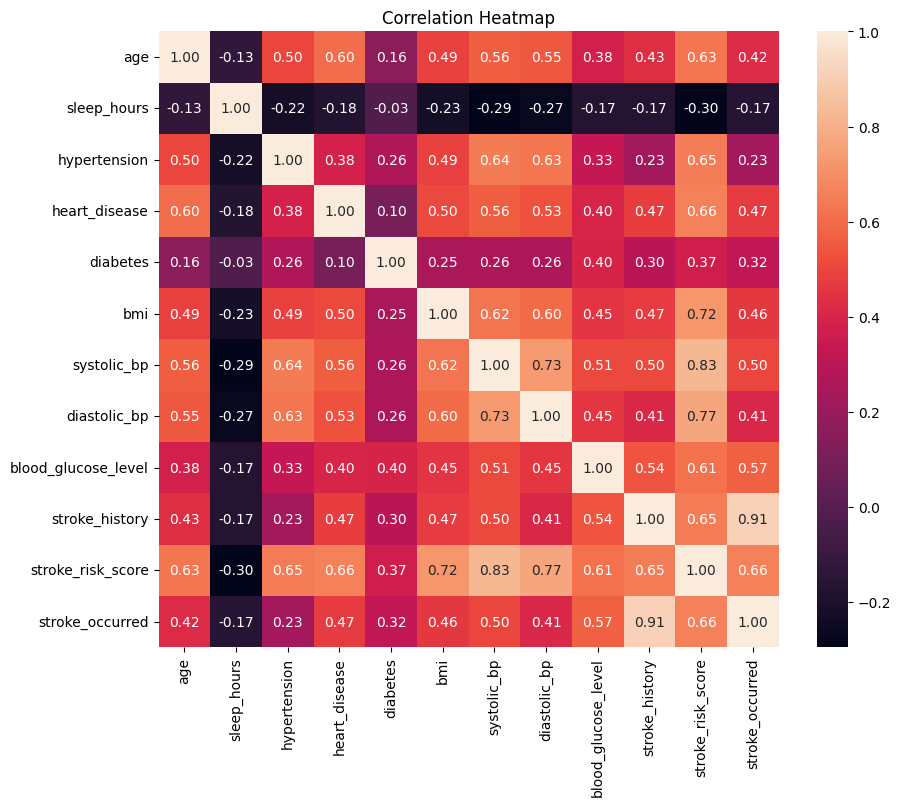

In [ ]:
# Correlation check
numeric_cols = [
    'age', 'sleep_hours', 'hypertension', 'heart_disease',
    'diabetes', 'bmi', 'systolic_bp', 'diastolic_bp',
    'blood_glucose_level', 'stroke_history', 'stroke_risk_score'
]

corr = df[numeric_cols + ['stroke_occurred']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# Unnecessary columns drop
df = df.drop(columns=['patient_id'])

In [ ]:
# visulaztion

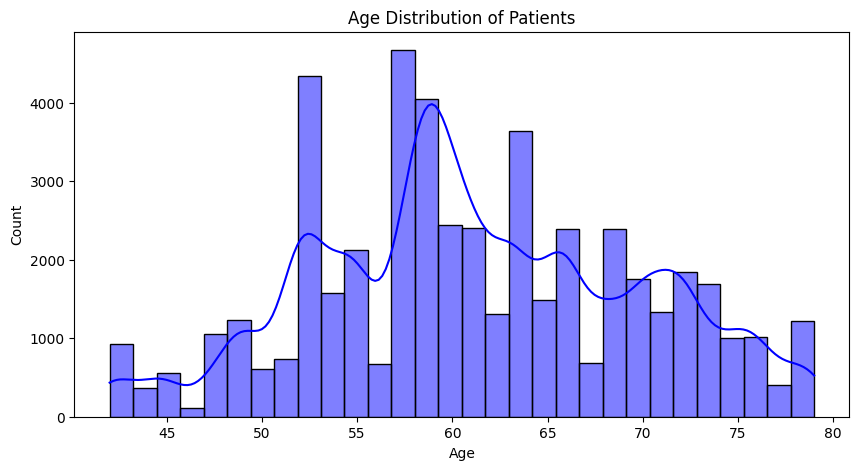

In [ ]:
# --------------------------
# 1. Age Distribution
# --------------------------
# plt.figure(figsize=(13,5))
# plt.hist(df['age'])
# plt.xlabel('Age')
# plt.ylabel('gender')
# plt.title('Age Distribution')
# plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df["age"], bins=30, kde=True,color="blue")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution of Patients")
plt.show()

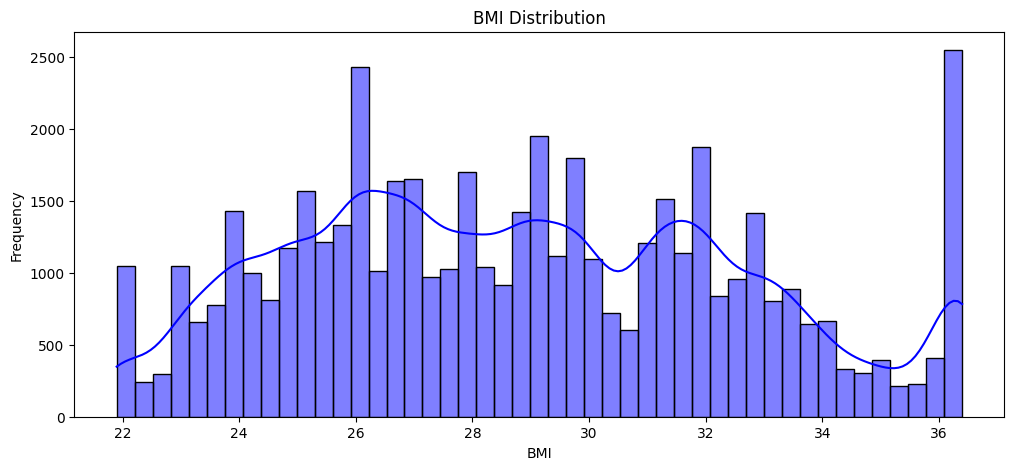

In [ ]:
# 2. BMI Distribution
# --------------------------
# plt.figure(figsize=(8,5))
# plt.hist(df['bmi'])
# plt.xlabel('BMI')
# plt.ylabel('Frequency')
# plt.title('BMI Distribution')
# plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df["bmi"], kde=True,color="blue")
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

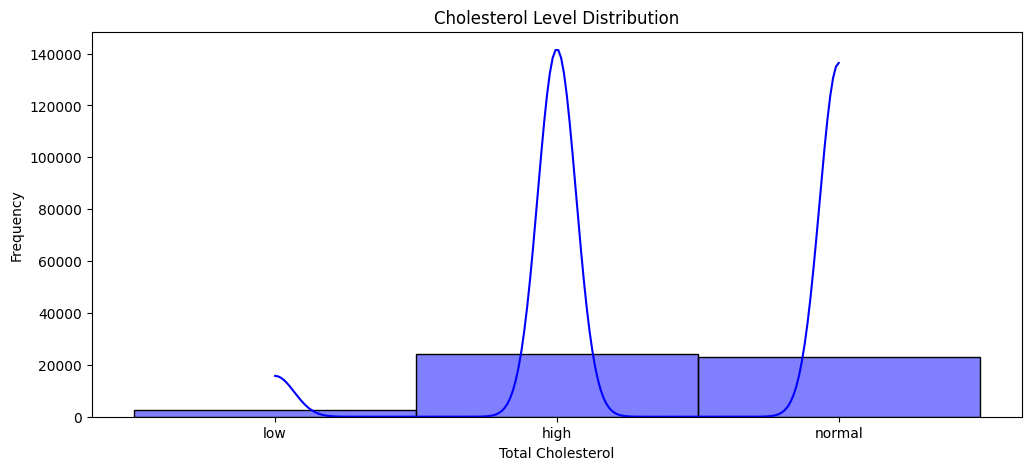

In [ ]:
# 3. Cholesterol Distribution
# --------------------------
# plt.figure(figsize=(8,5))
# plt.hist(df['cholesterol_total'])
# plt.xlabel('Cholesterol Total')
# plt.ylabel('Frequency')
# plt.title('Cholesterol Distribution')
# plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df['cholesterol_level'], kde=True,color="blue")
plt.title("Cholesterol Level Distribution")
plt.xlabel("Total Cholesterol")
plt.ylabel("Frequency")
plt.show()

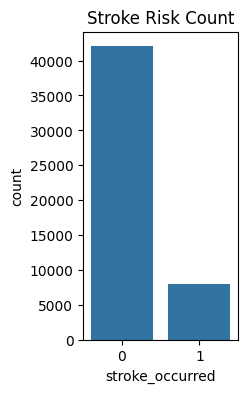

In [ ]:
# 4. Stroke Risk Count
# --------------------------
plt.figure(figsize=(2,4))
sns.countplot(x='stroke_occurred', data=df)
plt.title('Stroke Risk Count')
plt.show()

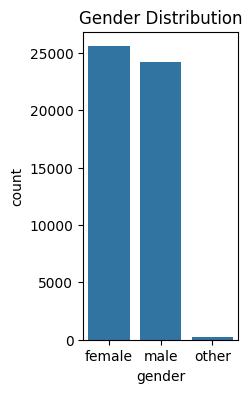

In [ ]:
# 5. Gender Count
# --------------------------
plt.figure(figsize=(2,4))
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.show()

In [ ]:
# Features (X) & Target (y)

X = df.drop(columns=['stroke_occurred'])
y = df['stroke_occurred']

In [ ]:
# One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

print(X_encoded.head())
print("Original shape:", X.shape)
print("Encoded shape:", X_encoded.shape)

   age  sleep_hours  hypertension  heart_disease  diabetes   bmi  systolic_bp  \
0   52          6.9             0              0         0  23.7          128   
1   72          6.1             1              1         0  36.4          156   
2   59          6.8             1              0         1  24.5          124   
3   68          6.5             1              1         1  32.4          156   
4   72          6.5             1              1         1  33.0          142   

   diastolic_bp  blood_glucose_level  stroke_history  ...  \
0            78                   98               0  ...   
1            92                  128               0  ...   
2            78                  198               0  ...   
3            96                  264               1  ...   
4            98                  264               1  ...   

   physical_activity_level_moderate  cholesterol_level_low  \
0                             False                   True   
1                     

In [ ]:
# Train–Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Random Forest Model Train

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=200,random_state=42,class_weight=None)

model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
# Train & Test Accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Training set prediction
y_train_pred = model.predict(X_train)

# Test set prediction
y_test_pred = model.predict(X_test)


In [ ]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.9812
